In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [26]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [27]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [2]:
df=df.drop(labels="Cabin",axis=1)


In [29]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64

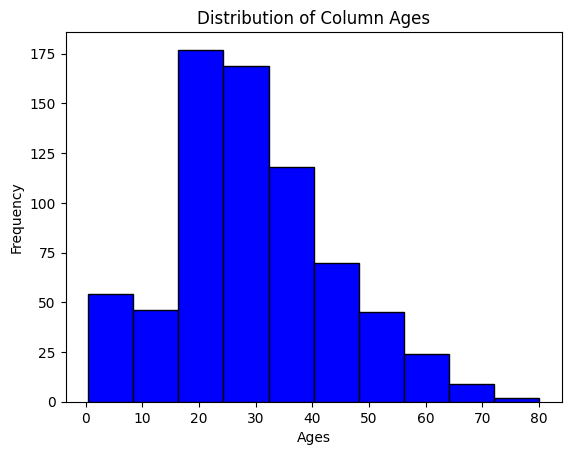

In [30]:
import matplotlib.pyplot as plt

plt.hist(df['Age'], bins=10, color='blue', edgecolor='black')
plt.title('Distribution of Column Ages')
plt.xlabel('Ages')
plt.ylabel('Frequency')
plt.show()


In [31]:
df[df["Age"].isnull()]["Pclass"].value_counts()

Pclass
3    136
1     30
2     11
Name: count, dtype: int64

In [32]:
df[df["Pclass"]== 3]["Age"].describe()


count    355.000000
mean      25.140620
std       12.495398
min        0.420000
25%       18.000000
50%       24.000000
75%       32.000000
max       74.000000
Name: Age, dtype: float64

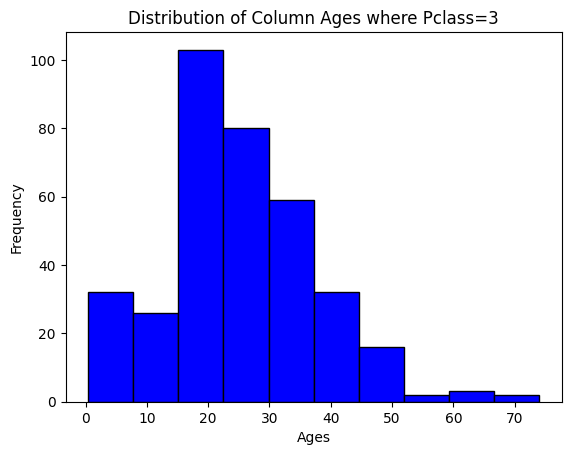

In [33]:
plt.hist(df[df["Pclass"]== 3]["Age"], bins=10, color='blue', edgecolor='black')
plt.title('Distribution of Column Ages where Pclass=3')
plt.xlabel('Ages')
plt.ylabel('Frequency')
plt.show()


In [34]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64

In [35]:
df["Age"].median()

28.0

In [3]:
# preprocessing pipeline implementation

# importing needed libraries

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Drop Name,ticket columns

df=df.drop(columns=["Name","Ticket"],axis=1)

# features, targets split

df=df.dropna(subset=['Embarked'])

features=df.drop('Survived',axis=1)
targets=df['Survived']

numeric_features = features.select_dtypes(include='number').columns.tolist()
categorical_features= features.select_dtypes(include='object').columns.tolist()






In [4]:
# Pipeline

def build_pipeline(model, categorical_encoder):
    
    # Numeric pipeline
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    
    # Categorical pipeline (pluggable)
    categorical_pipeline = Pipeline([
        
        ("encoder", categorical_encoder)
    ])
    
    # Combine
    preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ])
    
    # Final pipeline
    pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])
    
    return pipeline



# Logistic Regression (OneHot)

pipeline_lr = build_pipeline(
    LogisticRegression(max_iter=1000),
    OneHotEncoder(handle_unknown="ignore")
)


# RandomForest

pipeline_rf = build_pipeline(
    RandomForestClassifier(),
    OrdinalEncoder()
)










In [5]:

targets.value_counts()

Survived
0    549
1    340
Name: count, dtype: int64

In [6]:
cv_lr = cross_validate(pipeline_lr, features, targets, cv=5, scoring="accuracy")
cv_rf = cross_validate(pipeline_rf, features, targets, cv=5, scoring="accuracy")

In [10]:
print("Logistic Regression Accuracy:", cv_lr["test_score"].mean())
print("Random Forest Accuracy:", cv_rf["test_score"].mean())

Logistic Regression Accuracy: 0.7863073700247573
Random Forest Accuracy: 0.8099155716371484
